# El Niño and the seasonal wave climate: MOP transects at the tide gauges

Notebook 11 showed the seasonal cycle of sea level along the coast and the El Niño
pulse riding on top of it. Waves are the other half of the coastal water-level story:
wave setup and runup, not still-water level, do most of the damage in an El Niño
winter. This notebook asks the same two questions of the wave field that notebook 11
asked of sea level — what is the seasonal cycle, and what do El Niño winters add? —
first for the monthly mean, then for the top 2% of waves, which is where the damage
lives.

The wave data come from CDIP's MOP v1.1 system (O'Reilly et al., 2016), which
transforms offshore buoy spectra to roughly 100-m-spaced transects along the entire
California coast — about 11,600 of them. There is no MOP coverage in Oregon, so the
transect work covers the eight California gauges; South Beach and Astoria drop out.

Two limits shape the analysis before we start:

- **The hindcast begins in 2000.** MOP is driven by the modern directional buoy
  network, so 1982–83 and 1997–98 do not exist for waves. The event comparison rests
  on 2015–16, 2023–24, and the current 2026–27 event.
- **Tide gauges hide from waves.** Gauges are installed in harbors and bays precisely
  because waves are small there. The transect nearest each gauge is therefore often in
  a wave shadow — the site maps and section 5 show it — so each sheltered site also
  gets a deliberately chosen exposed transect nearby.

In [1]:
import re
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path
from urllib.request import urlopen, urlretrieve

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.colors import LightSource
from matplotlib.ticker import FuncFormatter, MaxNLocator
from PIL import Image

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name in ("notebooks", "reference"):
    PROJECT_ROOT = PROJECT_ROOT.parent
assert (PROJECT_ROOT / "README.md").exists(), "Open the course project folder first."

UHSLC_RAW = PROJECT_ROOT / "data" / "raw" / "uhslc"
MOP_RAW = PROJECT_ROOT / "data" / "raw" / "mop"
CODE_DL = PROJECT_ROOT / "data" / "code-downloaded"
MOP_RAW.mkdir(parents=True, exist_ok=True)
(CODE_DL / "basemaps").mkdir(parents=True, exist_ok=True)
print("MOP raw folder:", MOP_RAW)

MOP raw folder: /Users/holden/Documents/Scripps/Teaching/Climate_science_bootcamp/data/raw/mop


## 1. Matching gauges to transects

The UHSLC files carry each gauge's coordinates (`lat`, `lon` variables), and every MOP
transect publishes its own (`metaLatitude`, `metaLongitude`), so matching is a
nearest-neighbor problem. Transect IDs are a county code plus an alongshore number
(`D0513` = San Diego County; numbering runs south to north), which makes a
coarse-to-fine search cheap: probe every 50th transect in the gauge's county, then
every 10th near the best hit, then every one. `find_nearest_mop` below implements it;
it needs a few hundred tiny metadata requests, so the results are stored in `SITES`
and the search is off by default.

The `exposed` column is a set of choices, not algorithm output. Six gauges sit in
harbors or wave shadows, so each gets an alternate transect on the nearest *natural*
beach, screened three ways: away from jetties, breakwaters, and dredged channels
(their bathymetry is not a normal beach); carrying a satellite-derived slope fit; and,
among the clean candidates on each stretch, preferring the one with the strongest
winter runup so the event signal is vivid. The picks: Manhattan Beach (L0550) for the
Los Angeles harbor gauge, the Oceano–Pismo dune coast (SL075) for Port San Luis,
Marina State Beach (MO832) for Monterey, Ocean Beach (SF029) for San Francisco, the
Samoa spit well north of the entrance jetties (HU583) for Humboldt Bay, and Crescent
Beach (DN155) south of the harbor for Crescent City. La Jolla uses D0513, CDIP's
Scripps Pier validation transect and notebook 04's site.

In [2]:
# closest: nearest MOP transect to the gauge (La Jolla: D0513, the Scripps Pier
#   validation transect — nearest measured shore point to shore point, and the
#   same transect as notebook 04)
# exposed: hand-picked alternate on the nearest natural beach where the closest
#   transect sits in a wave shadow or against harbor structures (section 4)
SITES = [
    {"gauge": "San Diego",     "file": "d569.nc",  "closest": "D0179", "exposed": None},
    {"gauge": "La Jolla",      "file": "d554.nc",  "closest": "D0513", "exposed": None},
    {"gauge": "Los Angeles",   "file": "d567a.nc", "closest": "L0202", "exposed": "L0550"},
    {"gauge": "Port San Luis", "file": "d565a.nc", "closest": "SL165", "exposed": "SL075"},
    {"gauge": "Monterey",      "file": "d555a.nc", "closest": "MO762", "exposed": "MO832"},
    {"gauge": "San Francisco", "file": "d551.nc",  "closest": "SF077", "exposed": "SF029"},
    {"gauge": "Humboldt Bay",  "file": "d576a.nc", "closest": "HU533", "exposed": "HU583"},
    {"gauge": "Crescent City", "file": "d556.nc",  "closest": "DN196", "exposed": "DN155"},
]
for site in SITES:
    site["use"] = site["exposed"] or site["closest"]

MOP_DODS = "https://thredds.cdip.ucsd.edu/thredds/dodsC/cdip/model/MOP_alongshore"


def gauge_coords(filename):
    with xr.open_dataset(UHSLC_RAW / filename) as ds:
        lat = float(ds["lat"].values.squeeze())
        lon = float(ds["lon"].values.squeeze())
    return lat, lon - 360 if lon > 180 else lon


def mop_coords_remote(mop_id):
    """Read one transect's coordinates via a tiny OPeNDAP metadata request."""
    url = f"{MOP_DODS}/{mop_id}_nowcast.nc.ascii?metaLatitude,metaLongitude"
    text = urlopen(url, timeout=30).read().decode()
    return (float(re.search(r"metaLatitude, ([-\d.]+)", text).group(1)),
            float(re.search(r"metaLongitude, ([-\d.]+)", text).group(1)))


def haversine_km(lat1, lon1, lat2, lon2):
    p = np.pi / 180
    a = (np.sin((lat2 - lat1) * p / 2) ** 2
         + np.cos(lat1 * p) * np.cos(lat2 * p) * np.sin((lon2 - lon1) * p / 2) ** 2)
    return 2 * 6371 * np.arcsin(np.sqrt(a))


def find_nearest_mop(glat, glon, county, county_max):
    """Coarse-to-fine nearest-transect search within one county's numbering."""
    ndigits = 5 - len(county)
    best, bestd = None, np.inf
    for step, half in [(50, None), (10, 50), (1, 10)]:
        lo, hi = (1, county_max) if half is None else (best - half, best + half)
        for n in range(max(lo, 1), min(hi, county_max) + 1, step):
            try:
                lat, lon = mop_coords_remote(f"{county}{n:0{ndigits}d}")
            except Exception:
                continue
            d = haversine_km(glat, glon, lat, lon)
            if d < bestd:
                best, bestd = n, d
    return f"{county}{best:0{ndigits}d}", bestd


RUN_SEARCH = False  # True re-derives the closest transects (a few minutes, ~500 requests)

print(f"{'gauge':<14} {'gauge lat/lon':>20}   {'closest':>7} {'sep km':>7}   {'use':>6}")
for site in SITES:
    glat, glon = gauge_coords(site["file"])
    site["glat"], site["glon"] = glat, glon
    if RUN_SEARCH:
        county = re.match(r"[A-Z]+", site["closest"]).group(0)
        site["closest"], _ = find_nearest_mop(glat, glon, county, 1800)
    mlat, mlon = mop_coords_remote(site["closest"])
    d = haversine_km(glat, glon, mlat, mlon)
    print(f"{site['gauge']:<14} {glat:9.4f},{glon:10.4f}   {site['closest']:>7} "
          f"{d:7.2f}   {site['use']:>6}")

gauge                 gauge lat/lon   closest  sep km      use


San Diego        32.7133, -117.1733     D0179    4.60    D0179
La Jolla         32.8667, -117.2567     D0513    0.29    D0513


Los Angeles      33.7200, -118.2717     L0202    1.84    L0550


Port San Luis    35.1767, -120.7600     SL165    2.19    SL075
Monterey         36.6050, -121.8883     MO762    0.18    MO832


San Francisco    37.8067, -122.4650     SF077    0.17    SF029
Humboldt Bay     40.7667, -124.2167     HU533    1.93    HU583


Crescent City    41.7450, -124.1833     DN196    1.76    DN155


## 2. Site maps: transects, gauges, and the sea floor

Numbers in a table build no intuition. The maps below draw each gauge (star) and the
full MOP transects — a red model point on the ~10-m depth contour, connected by a red
line to a yellow beach anchor, one transect every ~100 m of coast — on a NOAA
topobathy elevation model, so you can see the harbor each gauge hides in, the open
coast each exposed transect samples, and the bathymetry in between.

The transect position, orientation (`metaShoreNormal`), and depth come from the same
metadata requests as section 1, cached to a CSV so the fetch (~700 tiny requests, a
couple of minutes) runs once. The model files do not carry CDIP's official back-beach
endpoints, so each beach anchor here is derived: march shoreward along the transect's
shore-normal until the elevation model rises above the waterline. The basemap tiles
come from NOAA NCEI's continuously updated DEM mosaic, fetched once per site as a
small GeoTIFF and cached alongside.

The anchors matter for more than the picture. A tide gauge is an onshore instrument,
so pinning it to a transect's *beach anchor* is more physical than pinning it to a
model point half a kilometer offshore — the table under the maps re-ranks the nearest
transect both ways.

While they load, a prediction to test: at La Jolla, find Scripps Submarine Canyon on
the map and ask what it should do to the waves a transect sees on either side of it.
And at the four sites with jetties and breakwaters — Los Angeles, Port San Luis,
Humboldt Bay, Crescent City — trace how far the exposed pick had to move from the
gauge before the coast looked like a beach again.

In [3]:
# (county, lo, hi) transect windows drawn on each site map
MAP_WINDOWS = {
    "San Diego":     [("D", 149, 209)],
    "La Jolla":      [("D", 470, 560)],
    "Los Angeles":   [("L", 172, 232), ("L", 450, 660)],
    "Port San Luis": [("SL", 40, 195)],
    "Monterey":      [("MO", 732, 862)],
    "San Francisco": [("SF", 1, 89)],
    "Humboldt Bay":  [("HU", 503, 660)],
    "Crescent City": [("DN", 130, 226)],
}
COORD_CSV = CODE_DL / "mop_transect_coords.csv"


def mop_meta_remote(mop_id):
    """Position, shore-normal bearing, and depth of one transect's model point."""
    url = (f"{MOP_DODS}/{mop_id}_nowcast.nc.ascii?"
           "metaLatitude,metaLongitude,metaShoreNormal,metaWaterDepth")
    text = urlopen(url, timeout=30).read().decode()
    grab = lambda k: float(re.search(k + r", ([-\d.]+)", text).group(1))
    return {"mop_id": mop_id, "lat": grab("metaLatitude"), "lon": grab("metaLongitude"),
            "shore_normal": grab("metaShoreNormal"), "depth": grab("metaWaterDepth")}


def fetch_transect_coords():
    """Metadata for every transect in MAP_WINDOWS, cached to COORD_CSV."""
    wanted = [f"{c}{n:0{5 - len(c)}d}"
              for ranges in MAP_WINDOWS.values() for c, lo, hi in ranges
              for n in range(lo, hi + 1)]
    have = pd.DataFrame()
    if COORD_CSV.exists():
        have = pd.read_csv(COORD_CSV)
        if "shore_normal" not in have.columns:
            have = pd.DataFrame()  # older cache without orientation; refetch
        else:
            have = have.set_index("mop_id")
    missing = [m for m in wanted if m not in have.index]
    if missing:
        print(f"fetching metadata for {len(missing)} transects ...")
        with ThreadPoolExecutor(max_workers=12) as pool:
            new = pd.DataFrame(list(pool.map(mop_meta_remote, missing))).set_index("mop_id")
        have = pd.concat([have, new]).sort_index()
        have.to_csv(COORD_CSV)
    return have


DEM_URL = ("https://gis.ngdc.noaa.gov/arcgis/rest/services/DEM_mosaics/"
           "DEM_global_mosaic/ImageServer/exportImage")


def fetch_dem(slug, bbox, px=650):
    """NOAA NCEI topobathy DEM for bbox=(w, s, e, n) as float32 metres, cached."""
    tag = "_".join(f"{b:.3f}" for b in bbox)
    target = CODE_DL / "basemaps" / f"{slug}_{tag}.tif"
    if not target.exists():
        w, s, e, n = bbox
        size = f"{px},{int(px * (n - s) / (e - w))}"
        url = (f"{DEM_URL}?bbox={w},{s},{e},{n}&bboxSR=4326&imageSR=4326"
               f"&size={size}&format=tiff&pixelType=F32&f=image")
        urlretrieve(url, target)
    z = np.array(Image.open(target)).astype(float)
    z[np.abs(z) > 12000] = np.nan  # server nodata
    return z


coords = fetch_transect_coords()
print(f"{len(coords)} transect coordinates loaded")

1116 transect coordinates loaded


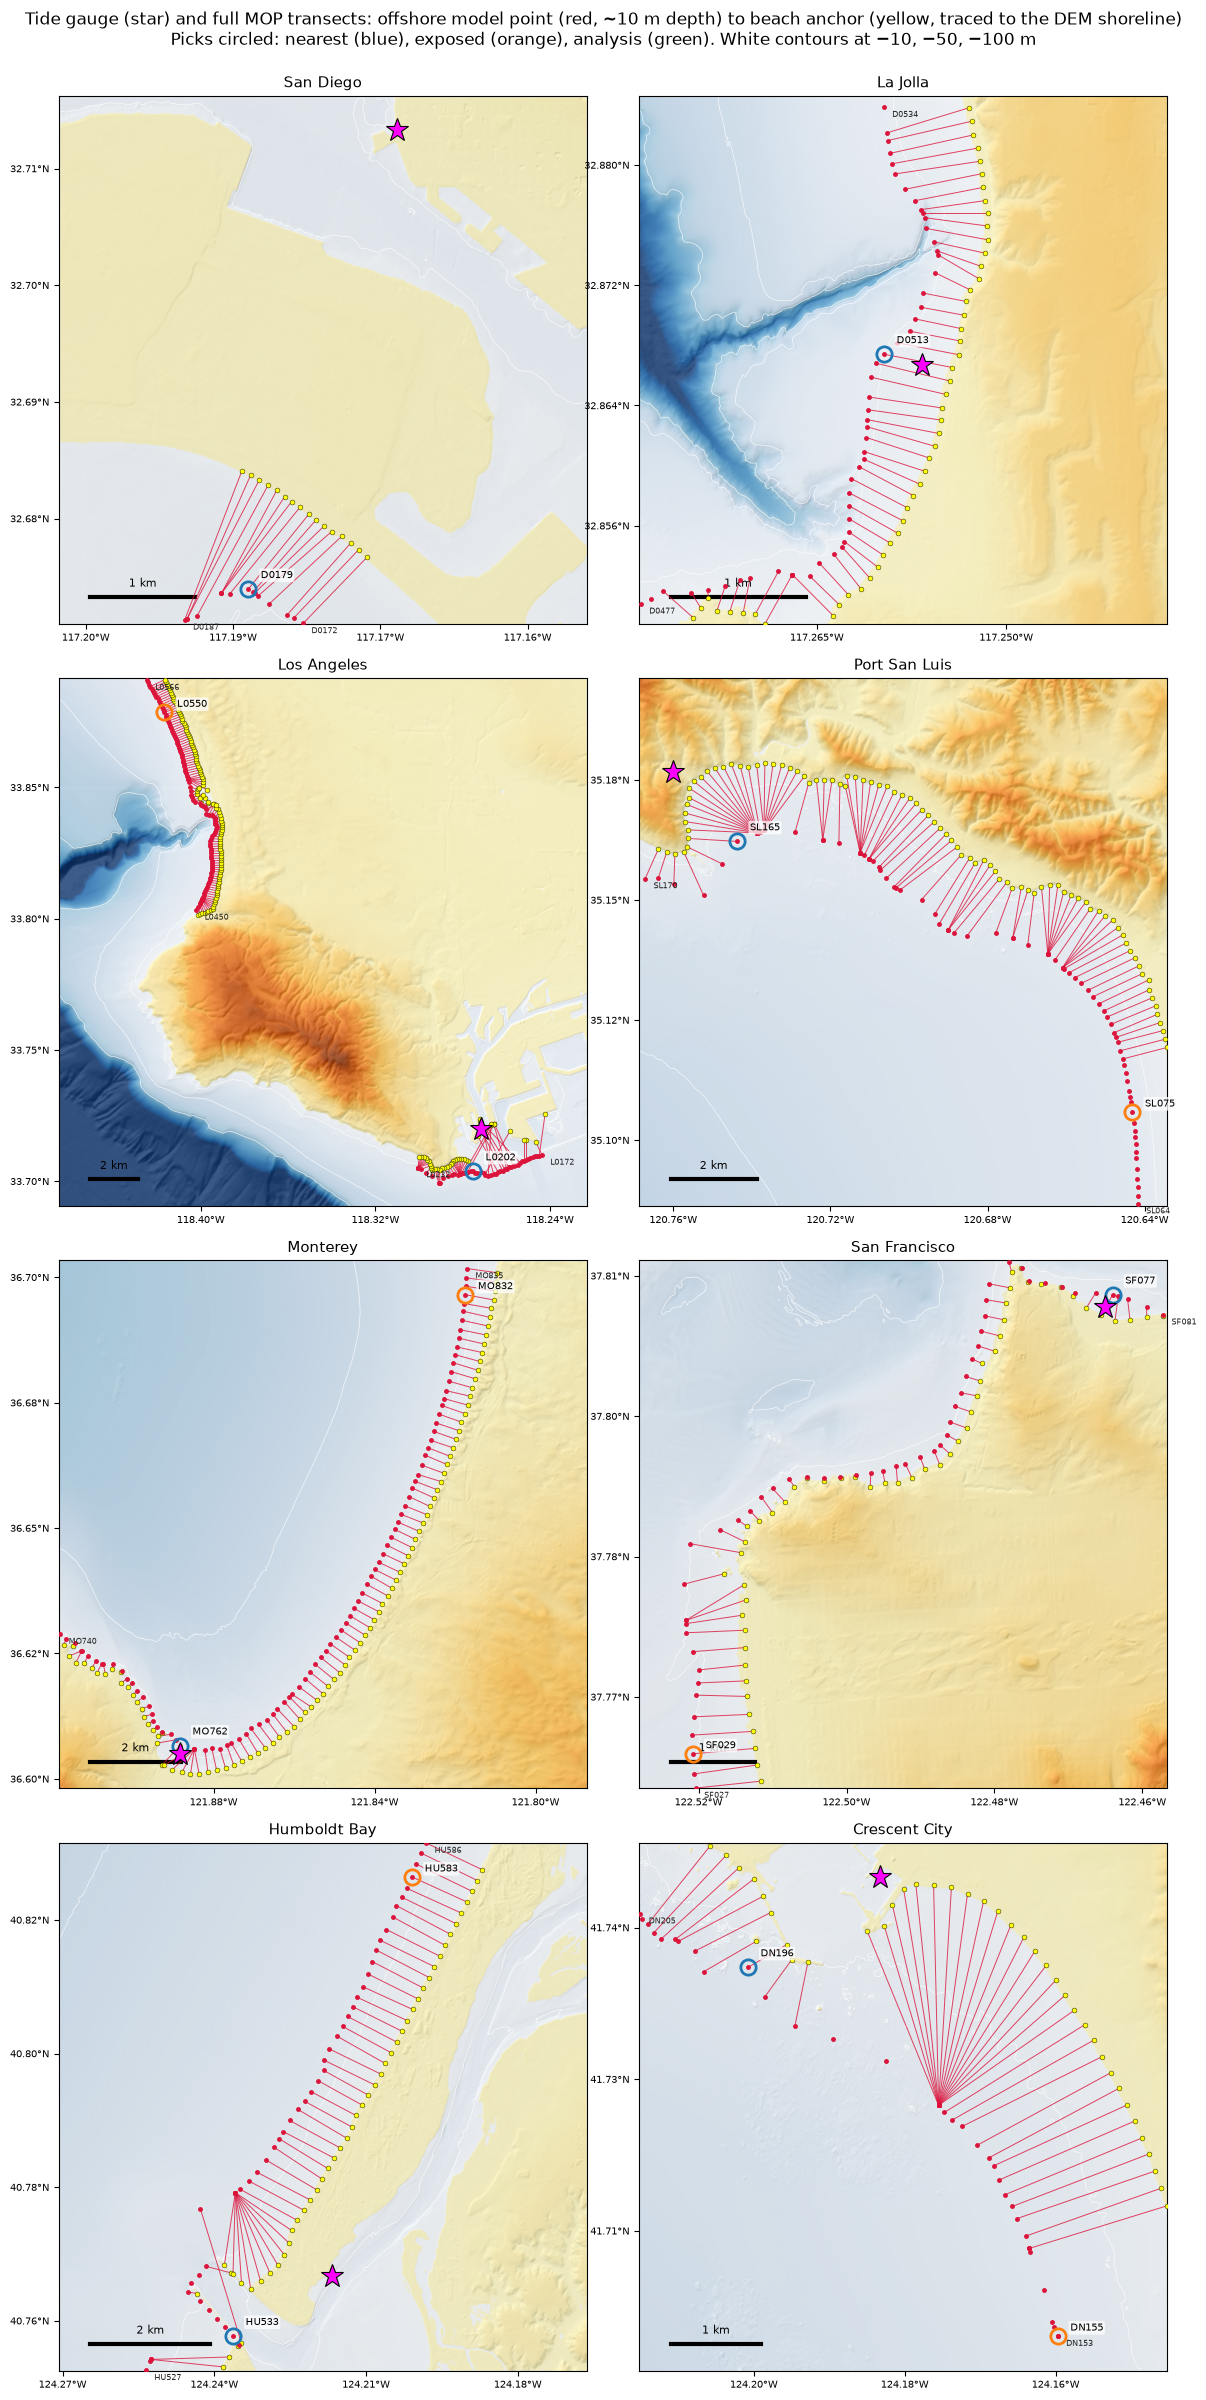

Nearest transect to each gauge, by offshore model point vs by beach anchor:
  San Diego      model point: D0179 ( 4.60 km)   beach anchor: D0187 ( 3.57 km)  <- ranking changes
  La Jolla       model point: D0514 ( 0.25 km)   beach anchor: D0513 ( 0.23 km)  <- ranking changes
  Los Angeles    model point: L0202 ( 1.84 km)   beach anchor: L0190 ( 0.04 km)  <- ranking changes
  Port San Luis  model point: SL165 ( 2.19 km)   beach anchor: SL159 ( 0.52 km)  <- ranking changes
  Monterey       model point: MO762 ( 0.18 km)   beach anchor: MO764 ( 0.41 km)  <- ranking changes
  San Francisco  model point: SF077 ( 0.17 km)   beach anchor: SF077 ( 0.11 km)
  Humboldt Bay   model point: HU533 ( 1.93 km)   beach anchor: HU550 ( 0.87 km)  <- ranking changes
  Crescent City  model point: DN196 ( 1.76 km)   beach anchor: DN187 ( 0.29 km)  <- ranking changes


In [4]:
def site_bbox(site, pad=0.15, min_half_km=1.7):
    """Bounding box around a site's gauge and its picked transects (tight zoom)."""
    pts_lat = [site["glat"]]
    pts_lon = [site["glon"]]
    for role in ("closest", "exposed", "use"):
        mop_id = site[role]
        if mop_id is not None and mop_id in coords.index:
            pts_lat.append(coords.loc[mop_id, "lat"])
            pts_lon.append(coords.loc[mop_id, "lon"])
    lat0 = (min(pts_lat) + max(pts_lat)) / 2
    lon0 = (min(pts_lon) + max(pts_lon)) / 2
    coslat = np.cos(np.deg2rad(lat0))
    # equal north-south and east-west extent in km, so every panel is square
    half_km = max((max(pts_lat) - min(pts_lat)) / 2 * 111.3,
                  (max(pts_lon) - min(pts_lon)) / 2 * 111.3 * coslat,
                  min_half_km) * (1 + pad)
    half_lat = half_km / 111.3
    half_lon = half_km / (111.3 * coslat)
    return (lon0 - half_lon, lat0 - half_lat, lon0 + half_lon, lat0 + half_lat)


def draw_basemap(ax, z, bbox):
    """Topobathy: blues below sea level, tans above, hillshaded."""
    w, s, e, n = bbox
    extent = (w, e, s, n)
    zf = np.where(np.isnan(z), 0.0, z)
    sea = np.ma.masked_where(zf >= 0, zf)
    land = np.ma.masked_where(zf < 0, zf)
    ax.imshow(sea, cmap="Blues_r", vmin=-250, vmax=0, extent=extent, origin="upper")
    ax.imshow(land, cmap="YlOrBr", vmin=-60, vmax=500, extent=extent, origin="upper")
    shade = LightSource(315, 45).hillshade(zf, vert_exag=3, dx=30, dy=30)
    ax.imshow(shade, cmap="gray", alpha=0.22, extent=extent, origin="upper")
    lon_grid = np.linspace(w, e, z.shape[1])
    lat_grid = np.linspace(n, s, z.shape[0])
    ax.contour(lon_grid, lat_grid, zf, levels=[-100, -50, -10], colors="w",
               linewidths=0.5, alpha=0.8, linestyles="-")


def trace_shore_anchor(lat, lon, shoreward_deg, z, bbox, max_m=2500, step_m=12):
    """March shoreward along the transect bearing until the DEM rises above
    +0.5 m; the crossing approximates the transect's beach anchor point."""
    w, s, e, n = bbox
    theta = np.deg2rad(shoreward_deg)
    coslat = np.cos(np.deg2rad(lat))
    for dist in np.arange(step_m, max_m, step_m):
        la = lat + np.cos(theta) * dist / 111320
        lo = lon + np.sin(theta) * dist / (111320 * coslat)
        row = (n - la) / (n - s) * (z.shape[0] - 1)
        col = (lo - w) / (e - w) * (z.shape[1] - 1)
        if not (0 <= row < z.shape[0] and 0 <= col < z.shape[1]):
            return None
        if z[int(row), int(col)] > 0.5:
            return la, lo
    return None


anchors = {}  # (gauge, mop_id) -> beach anchor (lat, lon); reused below
fig, axes = plt.subplots(4, 2, figsize=(12, 24))
for ax, site in zip(axes.flat, SITES):
    bbox = site_bbox(site)
    w, s, e, n = bbox
    z = fetch_dem(site["gauge"].lower().replace(" ", "_"), bbox)
    draw_basemap(ax, z, bbox)
    for c, lo_n, hi_n in MAP_WINDOWS[site["gauge"]]:
        ids = [f"{c}{k:0{5 - len(c)}d}" for k in range(lo_n, hi_n + 1)]
        sel = coords.loc[coords.index.intersection(ids)]
        sel = sel[(sel.lat > s) & (sel.lat < n) & (sel.lon > w) & (sel.lon < e)]
        if not len(sel):
            continue
        for mop_id, row in sel.iterrows():
            anchor = trace_shore_anchor(row.lat, row.lon,
                                        (row.shore_normal + 180) % 360, z, bbox)
            if anchor is not None:
                anchors[(site["gauge"], mop_id)] = anchor
                ax.plot([row.lon, anchor[1]], [row.lat, anchor[0]],
                        color="crimson", lw=0.7, alpha=0.8, zorder=3)
                ax.plot(anchor[1], anchor[0], "o", color="yellow", ms=3.5,
                        mec="k", mew=0.3, zorder=4)
        ax.plot(sel.lon, sel.lat, "o", color="crimson", ms=2.5, zorder=4)
        for end in (sel.index[0], sel.index[-1]):
            ax.annotate(end, (coords.loc[end, "lon"], coords.loc[end, "lat"]),
                        textcoords="offset points", xytext=(6, -7),
                        fontsize=6, color="0.15", zorder=6)
    picks = [("closest", "tab:blue"), ("exposed", "tab:orange")]
    if site["use"] not in (site["closest"], site["exposed"]):
        picks.append(("use", "tab:green"))
    for role, color in picks:
        mop_id = site[role]
        if mop_id is None or mop_id not in coords.index:
            continue
        row = coords.loc[mop_id]
        offset = {"closest": (9, 8), "exposed": (9, 4), "use": (9, -14)}[role]
        ax.plot(row.lon, row.lat, "o", mfc="none", mec=color, ms=11, mew=2, zorder=5)
        ax.annotate(mop_id, (row.lon, row.lat), textcoords="offset points",
                    xytext=offset, fontsize=7.5, color="k", zorder=6,
                    bbox=dict(boxstyle="round,pad=0.15", fc="w", ec="none", alpha=0.75))
    ax.plot(site["glon"], site["glat"], "*", color="magenta", ms=17, mec="k",
            mew=0.8, zorder=5)
    coslat = np.cos(np.deg2rad((s + n) / 2))
    width_km = (e - w) * 111.3 * coslat
    bar_km = 1 if width_km < 7 else 2
    bar_deg = bar_km / (111.3 * coslat)
    ax.plot([w + 0.06 * (e - w), w + 0.06 * (e - w) + bar_deg],
            [s + 0.05 * (n - s)] * 2, "k-", lw=3)
    ax.annotate(f"{bar_km} km", (w + 0.06 * (e - w) + bar_deg / 2, s + 0.07 * (n - s)),
                ha="center", fontsize=8)
    ax.set_xlim(w, e)
    ax.set_ylim(s, n)
    ax.set_aspect(1 / coslat)
    ax.set_title(site["gauge"], fontsize=11)
    ax.xaxis.set_major_locator(MaxNLocator(4))
    ax.yaxis.set_major_locator(MaxNLocator(5))
    dec = 3 if (n - s) < 0.045 else 2
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _, d=dec: f"{abs(x):.{d}f}°W"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _, d=dec: f"{y:.{d}f}°N"))
    ax.tick_params(labelsize=7)
fig.suptitle("Tide gauge (star) and full MOP transects: offshore model point "
             "(red, ~10 m depth) to beach anchor (yellow, traced to the DEM "
             "shoreline)\nPicks circled: nearest (blue), exposed (orange), "
             "analysis (green). White contours at −10, −50, −100 m",
             y=0.998, fontsize=12)
fig.tight_layout()
plt.show()

print("Nearest transect to each gauge, by offshore model point vs by beach anchor:")
for site in SITES:
    gauge = site["gauge"]
    by_model, by_anchor = [], []
    for c, lo_n, hi_n in MAP_WINDOWS[gauge]:
        ids = [f"{c}{k:0{5 - len(c)}d}" for k in range(lo_n, hi_n + 1)]
        for mop_id in coords.index.intersection(ids):
            row = coords.loc[mop_id]
            by_model.append((haversine_km(site["glat"], site["glon"],
                                          row.lat, row.lon), mop_id))
            if (gauge, mop_id) in anchors:
                alat, alon = anchors[(gauge, mop_id)]
                by_anchor.append((haversine_km(site["glat"], site["glon"],
                                               alat, alon), mop_id))
    dm, im = min(by_model)
    da, ia = min(by_anchor)
    note = "" if ia == im else "  <- ranking changes"
    print(f"  {gauge:<14} model point: {im} ({dm:5.2f} km)   "
          f"beach anchor: {ia} ({da:5.2f} km){note}")

Read the maps with the sheltering question in mind. The San Diego and Los Angeles
gauges sit well inside their bays; San Francisco's is inside the Golden Gate, with
SF077 beside it in flat water and SF029 out on Ocean Beach. Monterey's nearest
transect hides in the harbor's lee while MO832 faces the open bay mouth. At Humboldt
and Crescent City the whole gauge neighborhood is engineered — entrance jetties,
dredged channels, breakwaters — so the exposed picks sit 5–7 km away on the Samoa
spit and Crescent Beach, the nearest coast that is actually a beach.

## 3. Download and load the wave data

Each transect has an hourly `_hindcast` file (2000 through early 2025) and a rolling
`_nowcast` file that continues to the present; concatenating them gives a continuous
hourly record of significant wave height. We request only the bulk parameters through
the same NCSS service as notebook 04 and keep the responses in `data/raw/mop/`.
Hours flagged bad by `waveFlagPrimary` become NaN — at the two northernmost sites
that removes 15–25% of the record, mostly early years when buoy coverage up there
was thin.

In [5]:
MOP_NCSS = "https://thredds.cdip.ucsd.edu/thredds/ncss/point/cdip/model/MOP_alongshore"
MOP_VARS = "var=waveHs&var=waveTp&var=waveDp&var=waveFlagPrimary"


def fetch_mop(mop_id, kind):
    """Download one MOP transect file (kind: 'hindcast' or 'nowcast') if not present."""
    target = MOP_RAW / f"{mop_id}_{kind}.nc"
    if target.exists():
        return target
    url = f"{MOP_NCSS}/{mop_id}_{kind}.nc?{MOP_VARS}&temporal=all&accept=netcdf"
    urlretrieve(url, target)
    print(f"downloaded {target.name}")
    return target


def load_hourly_hs(mop_id):
    """Hourly significant wave height (m), 2000-present, quality-flagged."""
    parts = []
    for kind in ("hindcast", "nowcast"):
        with xr.open_dataset(fetch_mop(mop_id, kind)) as ds:
            ds = ds.swap_dims({"obs": "time"})
            hs = ds["waveHs"].to_series()
            # QC: keep only hours the model flags as good (flag == 1)
            hs[ds["waveFlagPrimary"].to_series() != 1] = np.nan
            parts.append(hs)
    hs = pd.concat(parts).sort_index()
    return hs[~hs.index.duplicated()]   # hindcast and nowcast overlap slightly


hs = load_hourly_hs("D0513")
print(f"D0513 hourly Hs: {hs.index[0]:%Y-%m-%d} to {hs.index[-1]:%Y-%m-%d}, "
      f"{hs.notna().mean():.1%} good")

D0513 hourly Hs: 2000-01-01 to 2026-08-13, 99.8% good


## 4. Monthly statistics, climatology, and the two-year window

The processing mirrors notebook 11 with one deliberate difference: **no detrending**.
Sea level carries a century of rise that would alias into any event comparison; the
wave record is 26 years on a fixed model, and wave-climate trends over that span are
small against its interannual variability, so we leave the series alone.

Two monthly statistics of the same hourly record, because they answer different
questions:

- the **monthly mean**, the wave analog of what notebook 11 did with sea level, and
- the **monthly 98th percentile**: rank a month's ~720 hourly Hs values and read off
  the value that the top 2% — the roughly fifteen roughest hours — exceed. Erosion
  and flooding care about those hours, not the average.

A month needs at least half its hours to count, except the current partial month,
which is kept and marked provisional. The mean gets the same 3-month smoothing as
notebook 11; the 98th percentile is deliberately left unsmoothed, so every point on
those curves is exactly the statistic just defined for exactly one month. The same
24-month event windows and line styles apply — 1982–83 and 1997–98 simply cannot
appear.

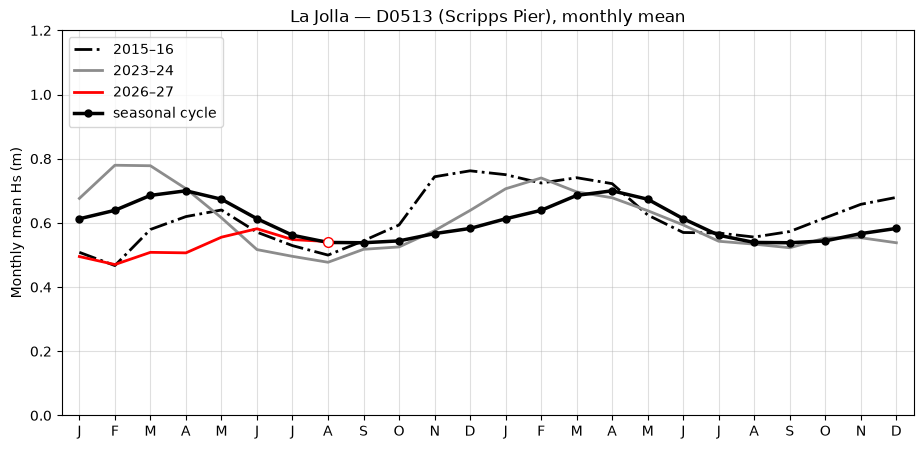

In [6]:
EVENTS = [
    (2015, "2015–16", dict(color="k", ls="-.", lw=2)),
    (2023, "2023–24", dict(color="0.55", ls="-", lw=2)),
    (2026, "2026–27", dict(color="r", ls="-", lw=2)),
]


def monthly_stat(hourly, stat):
    """Monthly statistic of hourly Hs: 'mean' or a quantile like 0.98.
    Months under 50% coverage are NaN; the final (possibly partial) month is
    kept if it has at least 3 days of data. Returns (series, partial_flag)."""
    grouped = hourly.resample("MS")
    values = grouped.mean() if stat == "mean" else grouped.quantile(stat)
    count = grouped.count()
    # coverage rules: a month needs half its ~720 hours to count, except the
    # current (partial) month, which is kept if it has at least 3 days so far
    keep_last = count.iloc[-1] >= 72
    last_value = values.iloc[-1]
    values[count < 360] = np.nan
    if keep_last:
        values.iloc[-1] = last_value
    return values, keep_last and count.iloc[-1] < 360


def smooth_3month(monthly):
    return monthly.rolling(3, center=True, min_periods=2).mean()


def seasonal_climatology(sl):
    return sl.groupby(sl.index.month).mean()


def two_year_window(sl, onset_year):
    idx = pd.date_range(f"{onset_year}-01-01", periods=24, freq="MS")
    return sl.reindex(idx).to_numpy()


def plot_two_year_cycle(ax, sl, title, partial_last=False):
    months = np.arange(1, 25)
    clim = seasonal_climatology(sl)
    for onset, label, style in EVENTS:
        window = two_year_window(sl, onset)
        if np.isnan(window).all():
            continue
        ax.plot(months, window, label=label, **style)
    # the 12-month climatology drawn twice, so both winters have a reference
    ax.plot(months, np.tile(clim.to_numpy(), 2), "k-o", lw=2.5, ms=5,
            markerfacecolor="k", label="seasonal cycle", zorder=2)
    if partial_last:
        window = two_year_window(sl, 2026)
        valid = np.where(~np.isnan(window))[0]
        if len(valid):
            ax.plot(valid[-1] + 1, window[valid[-1]], "o", ms=7,
                    markerfacecolor="white", markeredgecolor="r", zorder=5)
    ax.set_xticks(months)
    ax.set_xticklabels(list("JFMAMJJASOND") * 2)
    ax.set_xlim(0.5, 24.5)
    ax.set_title(title)
    ax.grid(alpha=0.4)


monthly, partial = monthly_stat(hs, "mean")
sl_lj = smooth_3month(monthly)

fig, ax = plt.subplots(figsize=(11, 5))
plot_two_year_cycle(ax, sl_lj, "La Jolla — D0513 (Scripps Pier), monthly mean", partial)
ax.set_ylabel("Monthly mean Hs (m)")
ax.set_ylim(0, 1.2)
ax.legend(loc="upper left")
plt.show()

Scripps Pier waves are mild, and the seasonal maximum lands in April rather than
January — surprising if you know these beaches in winter, so it is worth unpacking.
Point La Jolla strips most of the winter west-northwest swell by refraction, so what
remains at the pier is dominated by short-period windswell (the T < 7 s band carries
3–5 times the energy of the T > 11 s band here), and that band follows California's
spring wind maximum. The long-period swell band itself still peaks in December, the
way winter memory says it should — and April beats January in the monthly mean in 22
of the 27 years, so this is the climate, not one odd spring. A sheltered site
inherits the wind calendar, not the storm calendar. Keep that in mind while reading
the grids below.

## 5. The gauge hides from waves: closest vs exposed transects

Compare the mean wave height at the transect closest to each gauge with the exposed
alternate a few kilometers away — the quantitative version of what the maps showed.

In [7]:
print(f"{'gauge':<14} {'transect':>9} {'mean Hs':>8} {'clim range':>12} {'max mo':>7}")
for site in SITES:
    for role in ("closest", "exposed"):
        mop_id = site[role]
        if mop_id is None:
            continue
        monthly, _ = monthly_stat(load_hourly_hs(mop_id), "mean")
        clim = seasonal_climatology(smooth_3month(monthly))
        tag = f"{mop_id} ({role[0]})"
        print(f"{site['gauge']:<14} {tag:>9} {monthly.mean():7.2f}m "
          f"{clim.min():5.2f}-{clim.max():4.2f}m {clim.idxmax():>7}")

gauge           transect  mean Hs   clim range  max mo
San Diego      D0179 (c)    0.72m  0.51-0.96m       1


La Jolla       D0513 (c)    0.61m  0.54-0.70m       4


Los Angeles    L0202 (c)    0.49m  0.42-0.56m       2
Los Angeles    L0550 (e)    0.80m  0.67-0.92m       2
Port San Luis  SL165 (c)    0.75m  0.47-1.09m       1


Port San Luis  SL075 (e)    1.07m  0.75-1.42m       1
Monterey       MO762 (c)    0.48m  0.42-0.55m       5


Monterey       MO832 (e)    1.41m  1.04-1.74m       1


San Francisco  SF077 (c)    0.11m  0.09-0.12m       4
San Francisco  SF029 (e)    1.67m  1.06-2.32m       1
Humboldt Bay   HU533 (c)    0.63m  0.59-0.67m      11


Humboldt Bay   HU583 (e)    1.84m  1.35-2.32m       1
Crescent City  DN196 (c)    1.23m  0.80-1.66m       1


Crescent City  DN155 (e)    1.38m  0.90-1.91m       1


The transect nearest the San Francisco gauge (SF077, inside the Golden Gate) averages
0.11 m with no seasonal cycle to speak of; Ocean Beach (SF029), 8 km away, averages
1.7 m and peaks near 2.3 m in January. Monterey's nearest transect (MO762, tucked
behind the harbor) even has a late-spring maximum of local wind waves, while Marina
State Beach across the bay behaves like open coast. The wave panels below therefore
use the `use` transect for each site, labeled so nobody mistakes which ocean they are
looking at.

## 6. The wave transect grid: monthly means

Same construction as notebook 11's grid: two-year windows, climatology with markers,
events overlaid, north at the top, one common axis.

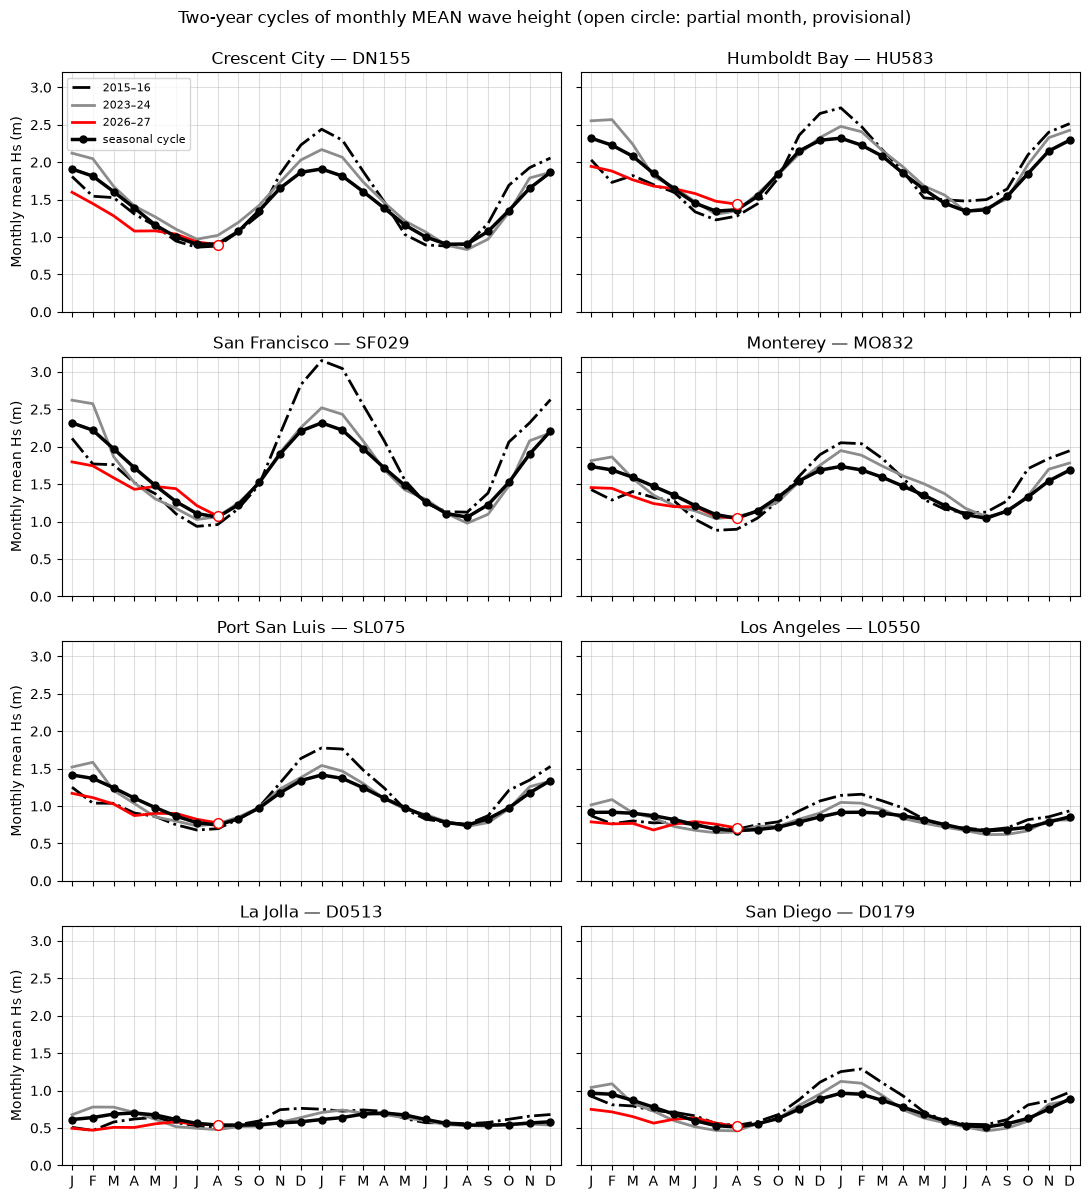

In [8]:
wave_records = []
for site in SITES:
    mean_m, partial = monthly_stat(load_hourly_hs(site["use"]), "mean")
    p98_m, _ = monthly_stat(load_hourly_hs(site["use"]), 0.98)
    wave_records.append({"gauge": site["gauge"], "mop": site["use"], "lat": site["glat"],
                         "mean": smooth_3month(mean_m), "p98": p98_m,
                         "partial": partial})

wave_records.sort(key=lambda r: r["lat"], reverse=True)

fig, axes = plt.subplots(4, 2, figsize=(11, 12), sharex=True, sharey=True)
for ax, rec in zip(axes.flat, wave_records):
    plot_two_year_cycle(ax, rec["mean"], f"{rec['gauge']} — {rec['mop']}", rec["partial"])
    ax.set_ylim(0, 3.2)
handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[0].legend(handles, labels, loc="upper left", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("Monthly mean Hs (m)")
fig.suptitle("Two-year cycles of monthly MEAN wave height "
             "(open circle: partial month, provisional)", y=0.995)
fig.tight_layout()
plt.show()

## 7. The same grid for the top 2% of waves

Monthly means smear fifteen hours of 6-m surf into thirty days of averaging. The
damage statistic is the monthly 98th percentile of hourly Hs — the top 2% the notebook
title of the next session is named for. Same format, only the y-axis grows.

One calibration before you look, because surf memory and monthly percentiles measure
different things. At Scripps, "there are waves above 2 m almost every winter" is true
of the *peak* — but a monthly p98 above 2 m requires ~15 hours over 2 m in a single
month, which is a sustained event, not a good afternoon:

In [9]:
lj_hs = load_hourly_hs("D0513")
lj_p98, _ = monthly_stat(lj_hs, 0.98)
djf = lj_p98[lj_p98.index.month.isin([12, 1, 2])]
annual_max = lj_hs.groupby(lj_hs.index.year).max()
print(f"D0513 winters (DJF), 2000-present:")
print(f"  years with at least one HOUR above 2 m:   "
      f"{(annual_max > 2).sum()} of {annual_max.notna().sum()}")
print(f"  DJF months with monthly p98 above 2 m:    "
      f"{(djf > 2).sum()} of {djf.notna().sum()}")
print(f"  median DJF monthly p98:                   {djf.median():.2f} m")

D0513 winters (DJF), 2000-present:
  years with at least one HOUR above 2 m:   24 of 27
  DJF months with monthly p98 above 2 m:    10 of 80
  median DJF monthly p98:                   1.52 m


Both of those first two lines are correct; they are different statistics. The
climatology below then averages stormy winters with calm ones, which pulls the black
curve lower still. When a plot of extremes looks "too low," the first question is
always *which* extreme statistic it shows.

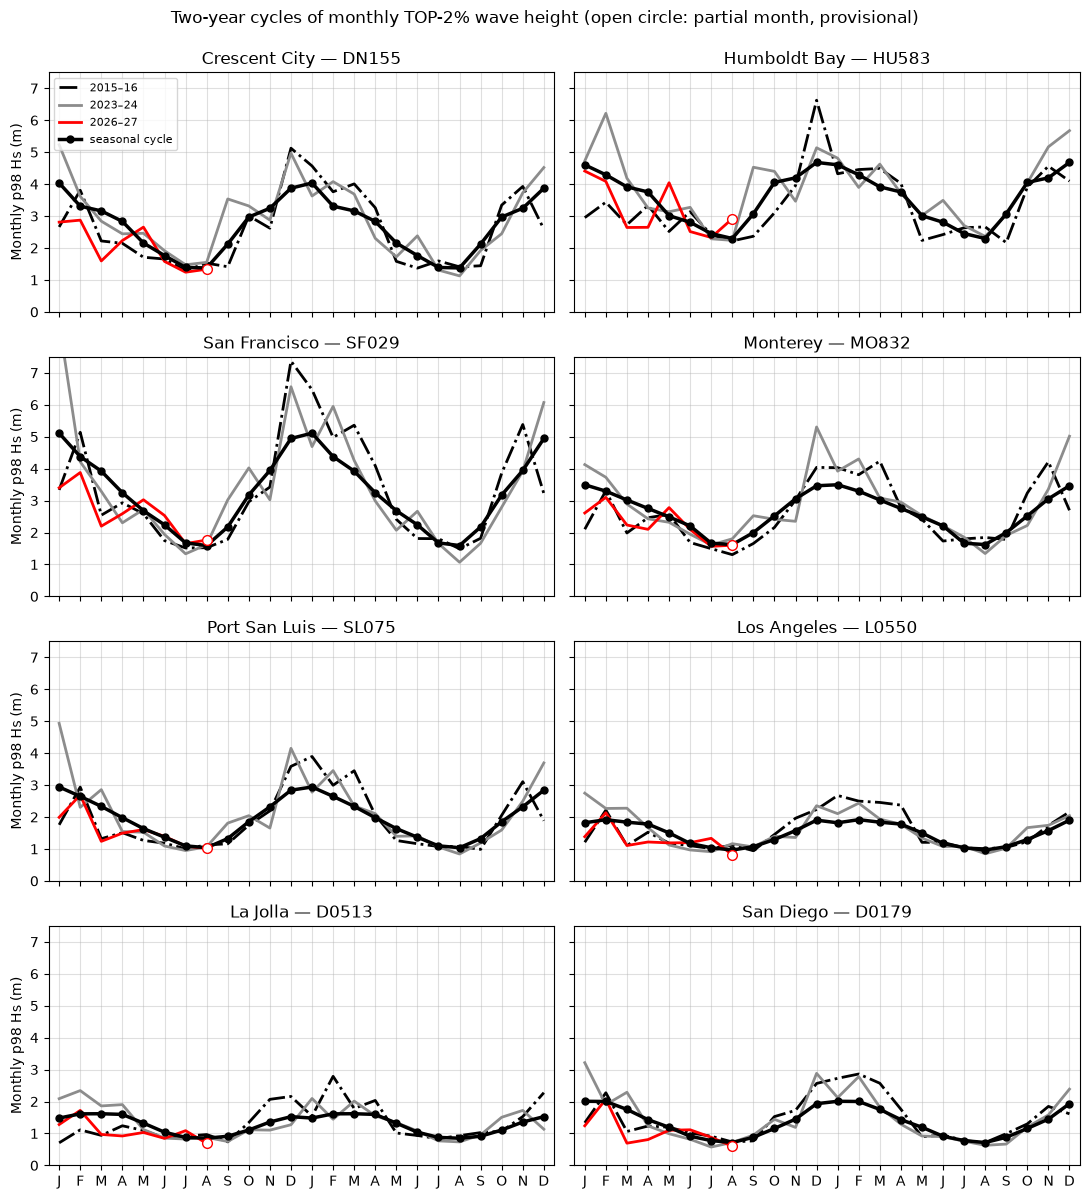

Departure of each event's roughest stretch above climatology (m):
  gauge          transect | mean 15-16  p98 15-16 | mean 23-24  p98 23-24
  Crescent City     DN155 |      +0.53      +1.25 |      +0.26      +1.41
  Humboldt Bay      HU583 |      +0.40      +1.95 |      +0.34      +1.93
  San Francisco     SF029 |      +0.83      +2.42 |      +0.35      +3.47
  Monterey          MO832 |      +0.38      +1.22 |      +0.21      +1.84
  Port San Luis     SL075 |      +0.39      +1.12 |      +0.21      +1.99
  Los Angeles       L0550 |      +0.24      +0.85 |      +0.17      +0.93
  La Jolla          D0513 |      +0.18      +1.17 |      +0.14      +0.73
  San Diego         D0179 |      +0.34      +0.86 |      +0.16      +1.21


In [10]:
fig, axes = plt.subplots(4, 2, figsize=(11, 12), sharex=True, sharey=True)
for ax, rec in zip(axes.flat, wave_records):
    plot_two_year_cycle(ax, rec["p98"], f"{rec['gauge']} — {rec['mop']}", rec["partial"])
    ax.set_ylim(0, 7.5)
handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[0].legend(handles, labels, loc="upper left", fontsize=8)
for ax in axes[:, 0]:
    ax.set_ylabel("Monthly p98 Hs (m)")
fig.suptitle("Two-year cycles of monthly TOP-2% wave height "
             "(open circle: partial month, provisional)", y=0.995)
fig.tight_layout()
plt.show()

print("Departure of each event's roughest stretch above climatology (m):")
print(f"  {'gauge':<14} {'transect':>8} | {'mean 15-16':>10} {'p98 15-16':>10} | "
      f"{'mean 23-24':>10} {'p98 23-24':>10}")
for rec in wave_records:
    row = [rec["gauge"], rec["mop"]]
    cols = []
    for stat in ("mean", "p98"):
        clim = seasonal_climatology(rec[stat])
        for onset in (2015, 2023):
            excess = two_year_window(rec[stat], onset) - np.tile(clim.to_numpy(), 2)
            cols.append(np.nanmax(excess))
    print(f"  {row[0]:<14} {row[1]:>8} | {cols[0]:+10.2f} {cols[2]:+10.2f} | "
          f"{cols[1]:+10.2f} {cols[3]:+10.2f}")

## 8. Waves against sea level: what stacks where

Put these grids next to notebook 11's and the total-water-level story assembles
itself:

- **Waves peak in winter everywhere.** Unlike sea level, whose seasonal maximum flips
  from September (south) to January (north), wave height peaks in December–January at
  every exposed California transect. There is no phase migration to hide behind.
- **El Niño amplifies the extremes more than the means.** Compare the paired columns
  in the table above: at Ocean Beach the 2015–16 winter added 0.8 m to the monthly
  mean but 2.4 m to the top-2% waves. The El Niño signal lives disproportionately in
  the storms.
- **The stack is worst in the north.** North of San Francisco an El Niño winter brings
  the seasonal sea level maximum, the El Niño sea level anomaly, and the seasonal wave
  maximum, all amplified, all in the same two or three months. In the south the water
  is already dropping when the big waves arrive.
- **2023–24 rewrites its own story in the extremes.** A strong event by tropical
  indices, a modest sea level response, a middling mean wave winter — and yet its
  top-2% columns beat 2015–16 at six of the eight sites, carried by the late-December
  2023 swell. Which event was "bigger" depends on the statistic, which is exactly why
  the total-water-level question (next notebook) needs both ingredients.

**In your groups:** take your station from notebook 11, use the site map to decide
which transect should represent it (defend the choice — distance is not the only
criterion), and build the mean and top-2% two-year plots. Where does your station's
2026–27 red curve sit as of this month?

Questions worth arguing about:

1. The El Niño sea level signal arrives partly as a coastally trapped wave from the
   south; the El Niño wave signal arrives as storms steered by a shifted jet. Should
   the two signals peak in the same month? Did they, in 2015–16?
2. The p98 grid still averages within calendar months. What would a
   duration-above-threshold statistic (hours per month with Hs > 4 m, say) show that
   a percentile hides, and when would you prefer it?
3. MOP starts in 2000. If you wanted the 1982–83 wave winter, what would you trust —
   buoy records, a global reanalysis hindcast, newspaper archives — and what would
   each miss?

## Data provenance

- CDIP MOP v1.1 alongshore transect model output (hourly bulk parameters), hindcast
  and nowcast files retrieved 2026-08-13 from
  `https://thredds.cdip.ucsd.edu/thredds/ncss/point/cdip/model/MOP_alongshore/` via
  NCSS (`waveHs`, `waveTp`, `waveDp`, `waveFlagPrimary`, all times).
- Model reference: O'Reilly, W. C., C. B. Olfe, J. Thomas, R. J. Seymour, and
  R. T. Guza (2016), *The California coastal wave monitoring and prediction system*,
  Coastal Engineering, 116, 118–132, doi:10.1016/j.coasteng.2016.06.005.
- Basemaps: NOAA NCEI continuously updated DEM Global Mosaic (topobathy; ArcGIS
  ImageServer `exportImage`, `gis.ngdc.noaa.gov`), fetched 2026-08-13, cached in
  `data/code-downloaded/basemaps/`.
- Transects matched to gauges by minimum great-circle distance, using gauge
  coordinates from the UHSLC NetCDF files (section 1). Exposed alternates were
  curated on the nearest natural beach to each gauge — clear of jetties,
  breakwaters, and dredged channels, holding a satellite slope fit, and preferring
  strong winter runup among clean candidates (L0550 Manhattan Beach, SL075 Oceano,
  MO832 Marina, SF029 Ocean Beach, HU583 Samoa spit, DN155 Crescent Beach).
  La Jolla uses D0513, the Scripps Pier validation transect from notebook 04.
- Raw responses live in `data/raw/mop/` and transect/basemap caches in
  `data/code-downloaded/`, all outside Git per the course data contract; the fetch
  cells regenerate everything from the providers.